In [134]:
import pandas as pd
from sqlalchemy import create_engine
import seaborn as sns


db_config = {'user': 'practicum_student',         # nombre de usuario
             'pwd': 's65BlTKV3faNIGhmvJVzOqhs', # contraseña
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432,              # puerto de conexión
             'db': 'data-analyst-final-project-db'}          # nombre de la base de datos

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(db_config['user'],
                                                                     db_config['pwd'],
                                                                       db_config['host'],
                                                                       db_config['port'],
                                                                       db_config['db'])

engine = create_engine(connection_string, connect_args={'sslmode':'require'})


PASO 1 - Exploración de la BD

1.1 Revisar tablas y relaciones

In [135]:
# consulta nombre de la bd 

db_config['db']


'data-analyst-final-project-db'

In [136]:
# Listar todas las tablas en el esquema público
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public';
"""
df = pd.read_sql(query, engine)
print("Tablas disponibles en la BD:")
print(df)

# inspección de columna books
query = """
SELECT column_name, data_type
FROM information_schema.columns
WHERE table_name = 'books';
"""
df = pd.read_sql(query, engine)
print("Estructura de la tabla 'author':")
print(df)

Tablas disponibles en la BD:
           table_name
0  advertisment_costs
1             authors
2               books
3           check_avg
4              orders
5          publishers
6             ratings
7             reviews
8              visits
Estructura de la tabla 'author':
        column_name data_type
0           book_id   integer
1         author_id   integer
2         num_pages   integer
3  publication_date      date
4      publisher_id   integer
5             title      text


In [137]:
df = pd.read_sql(query, engine)

In [138]:
# Imprimo las primeras filas de las tablas

tables = [
    "advertisment_costs", "authors", "books", "check_avg",
    "orders", "publishers", "ratings", "reviews", "visits"
]

for table in tables:
    query = f"SELECT * FROM {table} LIMIT 5"
    df = pd.read_sql(query, engine)

    print(f"\nTabla: {table}")
    print(df)


Tabla: advertisment_costs
   id  sourceid         dt   costs
0   1         1 2017-06-01  $75.20
1   2         1 2017-06-02  $62.25
2   3         1 2017-06-03  $36.53
3   4         1 2017-06-04  $55.00
4   5         1 2017-06-05  $57.08

Tabla: authors
   author_id                          author
0          1                      A.S. Byatt
1          2  Aesop/Laura Harris/Laura Gibbs
2          3                 Agatha Christie
3          4                   Alan Brennert
4          5        Alan Moore/David   Lloyd

Tabla: books
   book_id  author_id                                              title  \
0        1        546                                       'Salem's Lot   
1        2        465                 1 000 Places to See Before You Die   
2        3        407  13 Little Blue Envelopes (Little Blue Envelope...   
3        4         82  1491: New Revelations of the Americas Before C...   
4        5        125                                               1776   

   num

Paso 2 - Consultas

In [139]:

# 2.1 - Seleccionar el número de libros publicados desde 01-ene-2000
query = """
SELECT COUNT(*)
FROM books
WHERE publication_date > '2000-01-01'
"""
result = pd.read_sql(query, engine)

# extraer valor
num_books = result.squeeze()

print(f'Desde el 01-ene-2000, han sido publicados {num_books} libros')




Desde el 01-ene-2000, han sido publicados 819 libros


In [140]:
# 2.2 - Encontrar el número de reseñas de usuarios 
query = """
SELECT COUNT(*)
FROM reviews
"""
pd.read_sql(query, engine)

# extraer valor
num_reviews = result.squeeze()

print(f'Fueron registradas {num_reviews} reseñas por parte de los clientes')



Fueron registradas 819 reseñas por parte de los clientes


In [141]:
# 2.3 - Encontrar la calificación promedio / libro
query = """
SELECT books.title, 
        AVG(ratings.rating) AS avg_rating
FROM ratings    
INNER JOIN books 
ON ratings.book_id = books.book_id   
GROUP BY books.title
ORDER BY avg_rating DESC;
"""
pd.read_sql(query, engine)

,title,avg_rating
0,Captivating: Unveiling the Mystery of a Woman'...,5.00
1,Evening Class,5.00
2,In the Hand of the Goddess (Song of the Liones...,5.00
3,The Big Bad Wolf (Alex Cross #9),5.00
4,A Dirty Job (Grim Reaper #1),5.00
...,...,...
994,The World Is Flat: A Brief History of the Twen...,2.25
995,His Excellency: George Washington,2.00
996,Junky,2.00
997,Drowning Ruth,2.00


In [142]:
# 2.4 Editoriales con mayor número de libros publicados de más de 50 pg.

query = """
SELECT publisher, COUNT(book_id) AS num_books
FROM publishers    
INNER JOIN books 
ON publishers.publisher_id = books.publisher_id   
WHERE num_pages > 50
GROUP BY publisher
ORDER BY num_books DESC;

"""
pd.read_sql(query, engine)

,publisher,num_books
0,Penguin Books,42
1,Vintage,31
2,Grand Central Publishing,25
3,Penguin Classics,24
4,Ballantine Books,19
...,...,...
329,Turtleback,1
330,Atheneum Books for Young Readers: Richard Jack...,1
331,Penguin Signet,1
332,Victor Gollancz,1


In [143]:
# 2.5 Autor con más alta calificación promedio del libro (libros a partir de 50 calificaciones)

query = """
SELECT a.author, AVG(r.rating) AS avg_rating 
FROM authors a   
INNER JOIN books b
ON a.author_id = b.author_id 
INNER JOIN ratings r
ON b.book_id = r.book_id    
WHERE b.book_id IN(
        SELECT book_id
        FROM ratings
        GROUP BY book_id
        HAVING COUNT(*) >= 50
)
GROUP BY a.author
ORDER BY avg_rating DESC
LIMIT 1
"""
pd.read_sql(query, engine)

,author,avg_rating
0,J.K. Rowling/Mary GrandPré,4.287097


In [ ]:
# 2.6 número promedio de reseñas, entre usuarios con más de 50 libros calificados

query = """
SELECT AVG(review_count) AS avg_reviews              -- promedio final de reseñas
FROM (
    SELECT username, COUNT(*) AS review_count          -- número de reseñas por usuario
    FROM reviews
    WHERE username IN (
        SELECT username                              -- usuarios con muchas calificaciones
        FROM ratings
        GROUP BY username
        HAVING COUNT(DISTINCT book_id) > 50                 -- más de 50 libros calificados
    )
    GROUP BY username
)
"""
pd.io.sql.read_sql(query, con= engine)

# Ejecutar consulta
result = pd.read_sql(query, engine)

# Extraer valor
avg_reviews = result.squeeze()

# Mostrar resultado formateado
print(f"El número promedio de reseñas entre usuarios con más de 50 libros calificados es {avg_reviews:.2f}")

El número promedio de reseñas entre usuarios con más de 50 libros calificados es 24.33


Gráficos

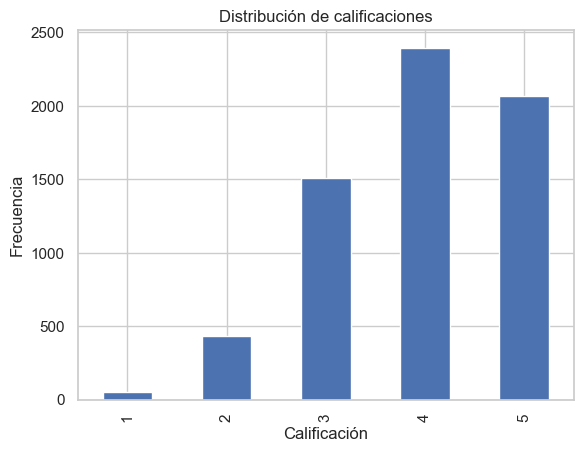

In [145]:
# Gráfico - Distribución de Calificaciones

query = "SELECT rating FROM ratings"
df_ratings = pd.read_sql(query, engine)

df_ratings['rating'].value_counts().sort_index().plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Distribución de calificaciones")
plt.xlabel("Calificación")
plt.ylabel("Frecuencia")
plt.show()

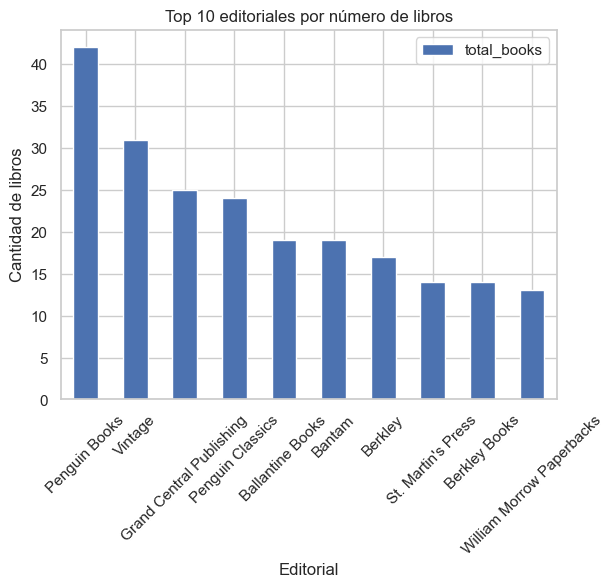

In [146]:
# Gráfico top 10 de editoriales por número de libros

query = """
SELECT p.publisher, COUNT(b.book_id) AS total_books
FROM publishers p
INNER JOIN books b ON p.publisher_id = b.publisher_id
GROUP BY p.publisher
ORDER BY total_books DESC
LIMIT 10
"""

df_publishers = pd.read_sql(query, engine)

df_publishers.plot(x='publisher', y='total_books', kind='bar')

plt.title("Top 10 editoriales por número de libros")
plt.xlabel("Editorial")
plt.ylabel("Cantidad de libros")
plt.xticks(rotation=45)
plt.show()

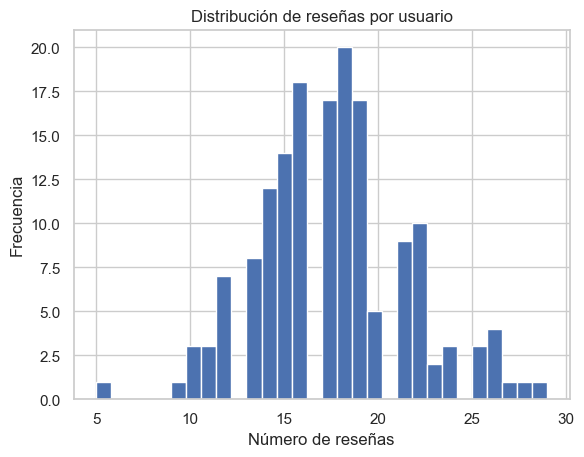

In [147]:
# Gráfico de reseñas por usuario

query = """
SELECT username, COUNT(*) as total_reviews
FROM reviews
GROUP BY username
"""
df_users = pd.read_sql(query, engine)

df_users['total_reviews'].plot(kind='hist', bins=30)

plt.title("Distribución de reseñas por usuario")
plt.xlabel("Número de reseñas")
plt.ylabel("Frecuencia")
plt.show()

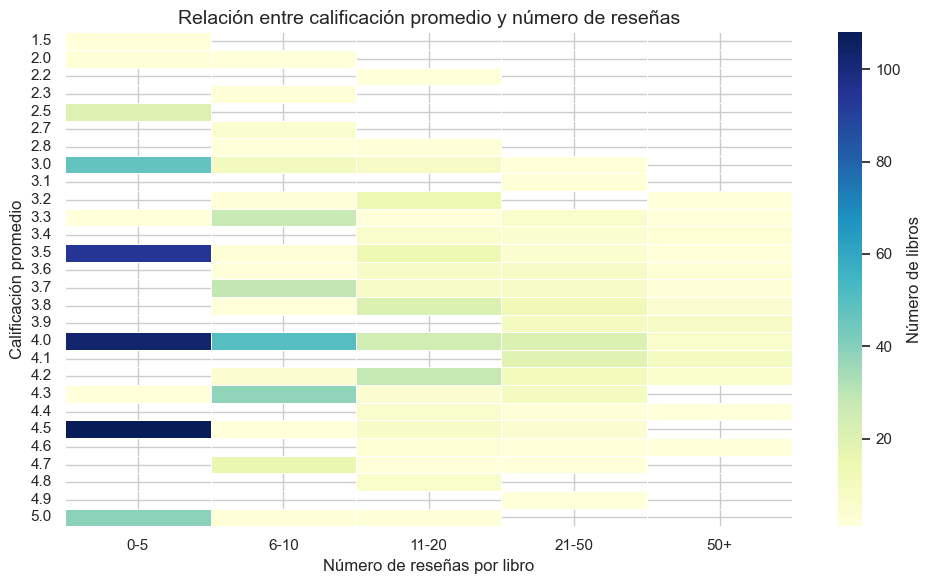

In [148]:

# Mapa de calor de distribución de libros según su calificación y popularidad




# 1. Query SQL
query = """
SELECT 
    b.book_id,
    AVG(rt.rating) AS avg_rating,
    COUNT(rv.review_id) AS num_reviews
FROM books b
LEFT JOIN ratings rt ON b.book_id = rt.book_id
LEFT JOIN reviews rv ON b.book_id = rv.book_id
GROUP BY b.book_id;
"""

# 2. Cargar datos
df = pd.read_sql(query, engine)

# 3. Crear variables
df['Calificación'] = df['avg_rating'].round(1)

df['Reseñas'] = pd.cut(
    df['num_reviews'],
    bins=[0, 5, 10, 20, 50, 100],
    labels=["0-5", "6-10", "11-20", "21-50", "50+"]
)

# 4. Tabla pivote
heatmap_data = df.pivot_table(
    index='Calificación',
    columns='Reseñas',
    values='book_id',
    aggfunc='count'
)

# 5. Ordenar eje
heatmap_data = heatmap_data.sort_index()

# 6. Heatmap limpio
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Número de libros'}
)

plt.title("Relación entre calificación promedio y número de reseñas", fontsize=14)
plt.xlabel("Número de reseñas por libro")
plt.ylabel("Calificación promedio")

plt.tight_layout()
plt.show()

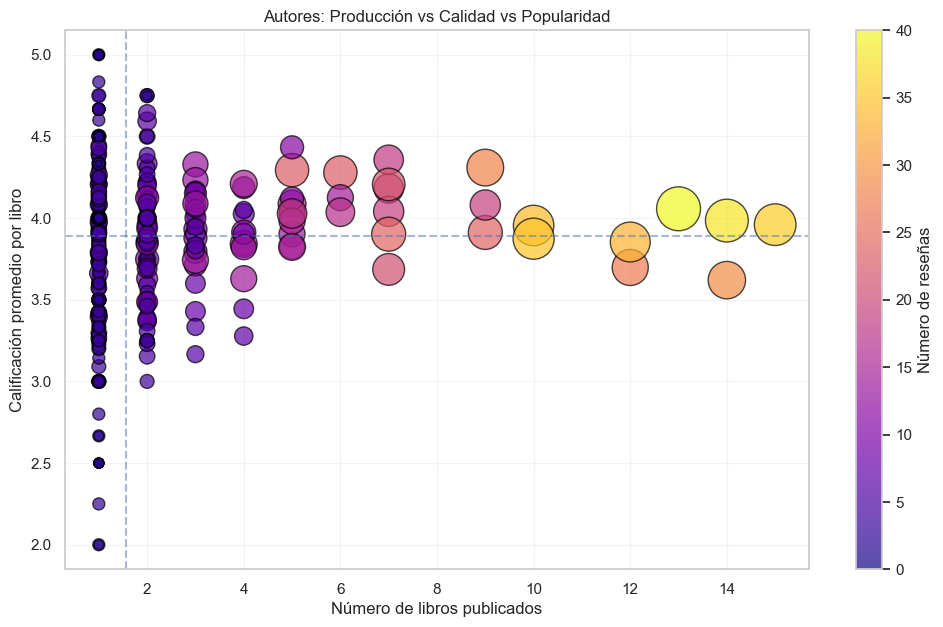

In [149]:
# Gráfico - Diagrama de dispersión con burbujas - Producción vs Calidad Vs Popularidad de Autores



# =========================
# DATOS POR AUTOR
# =========================
query_authors = """
SELECT 
    b.author_id,
    COUNT(DISTINCT b.book_id) AS num_books,
    AVG(r.rating) AS avg_rating,
    COUNT(DISTINCT rev.review_id) AS num_reviews
FROM books b
LEFT JOIN ratings r ON b.book_id = r.book_id
LEFT JOIN reviews rev ON b.book_id = rev.book_id
GROUP BY b.author_id
"""

df_authors = pd.read_sql(query_authors, engine)

# Escalar tamaño
df_authors['size'] = df_authors['num_reviews'] / df_authors['num_reviews'].max() * 1000

# =========================
# GRÁFICO
# =========================
plt.figure(figsize=(12,7))

scatter = plt.scatter(
    df_authors['num_books'], 
    df_authors['avg_rating'], 
    s=df_authors['size'], 
    c=df_authors['num_reviews'],   # color = popularidad
    cmap='plasma',
    alpha=0.7,
    edgecolors='black'
)

plt.colorbar(scatter, label='Número de reseñas')

plt.xlabel("Número de libros publicados")
plt.ylabel("Calificación promedio por libro")
plt.title("Autores: Producción vs Calidad vs Popularidad")

plt.axhline(df_authors['avg_rating'].mean(), linestyle='--', alpha=0.5)
plt.axvline(df_authors['num_books'].mean(), linestyle='--', alpha=0.5)

plt.grid(alpha=0.2)
plt.show()